# 💳 Credit Card Fraud Detection
**End-to-End ML Pipeline | Imbalanced Data | SMOTE | XGBoost | SHAP**

---
**Dataset**: [Kaggle Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Goal**: Detect fraudulent transactions with high recall while minimizing false positives.


## 📦 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

# Core ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost available')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not installed — skipping')

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print('✅ SHAP available')
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠️  SHAP not installed — skipping')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('\n✅ All imports successful')

✅ XGBoost available
✅ SHAP available

✅ All imports successful


## 📂 2. Load Dataset

In [2]:
# ─── Load Data ───────────────────────────────────────────────────────────────
# Option A: Local file (after Kaggle download)
DATA_PATH = 'C:/Users/HS COMPUTER/OneDrive/Desktop/Credit card fraud detection/data/creditcard.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'✅ Loaded from disk: {df.shape}')
else:
    # Option B: Synthetic demo data (same schema)
    print('⚠️  Dataset not found — generating synthetic demo data...')
    print('    Download the real dataset from:')
    print('    https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')
    print()

    n_legit  = 5000
    n_fraud  = 25   # ~0.5% fraud rate for demo
    n_total  = n_legit + n_fraud

    rng = np.random.RandomState(RANDOM_STATE)

    legit_data = rng.randn(n_legit, 28) * 0.8
    fraud_data = rng.randn(n_fraud, 28) * 1.5 + 0.3  # slightly shifted
    V_cols = np.vstack([legit_data, fraud_data])

    time_vals   = np.linspace(0, 172800, n_total)
    amount_legit = np.abs(rng.exponential(50, n_legit))
    amount_fraud = np.abs(rng.exponential(200, n_fraud))
    amount_vals  = np.concatenate([amount_legit, amount_fraud])
    labels       = np.concatenate([np.zeros(n_legit), np.ones(n_fraud)])

    df = pd.DataFrame(V_cols, columns=[f'V{i}' for i in range(1, 29)])
    df.insert(0,  'Time',   time_vals)
    df.insert(29, 'Amount', amount_vals)
    df['Class'] = labels.astype(int)

    idx = rng.permutation(n_total)
    df  = df.iloc[idx].reset_index(drop=True)
    print(f'✅ Synthetic dataset created: {df.shape}')

df.head()

✅ Loaded from disk: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 🔍 3. Data Understanding

In [3]:
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Shape       : {df.shape}')
print(f'Memory      : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print(f'Missing vals: {df.isnull().sum().sum()}')
print()

fraud   = df[df['Class'] == 1]
legit   = df[df['Class'] == 0]
fraud_pct = len(fraud) / len(df) * 100

print('CLASS DISTRIBUTION')
print('-' * 55)
print(f'Legitimate transactions : {len(legit):,}  ({100-fraud_pct:.4f}%)')
print(f'Fraudulent transactions : {len(fraud):,}  ({fraud_pct:.4f}%)')
print(f'Imbalance ratio         : {len(legit)//len(fraud)}:1')
print()
print('AMOUNT STATISTICS')
print('-' * 55)
print(df.groupby('Class')['Amount'].describe().round(2))

DATASET OVERVIEW
Shape       : (284807, 31)
Memory      : 70.63 MB
Missing vals: 0

CLASS DISTRIBUTION
-------------------------------------------------------
Legitimate transactions : 284,315  (99.8273%)
Fraudulent transactions : 492  (0.1727%)
Imbalance ratio         : 577:1

AMOUNT STATISTICS
-------------------------------------------------------
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


## 📊 4. Exploratory Data Analysis (EDA)

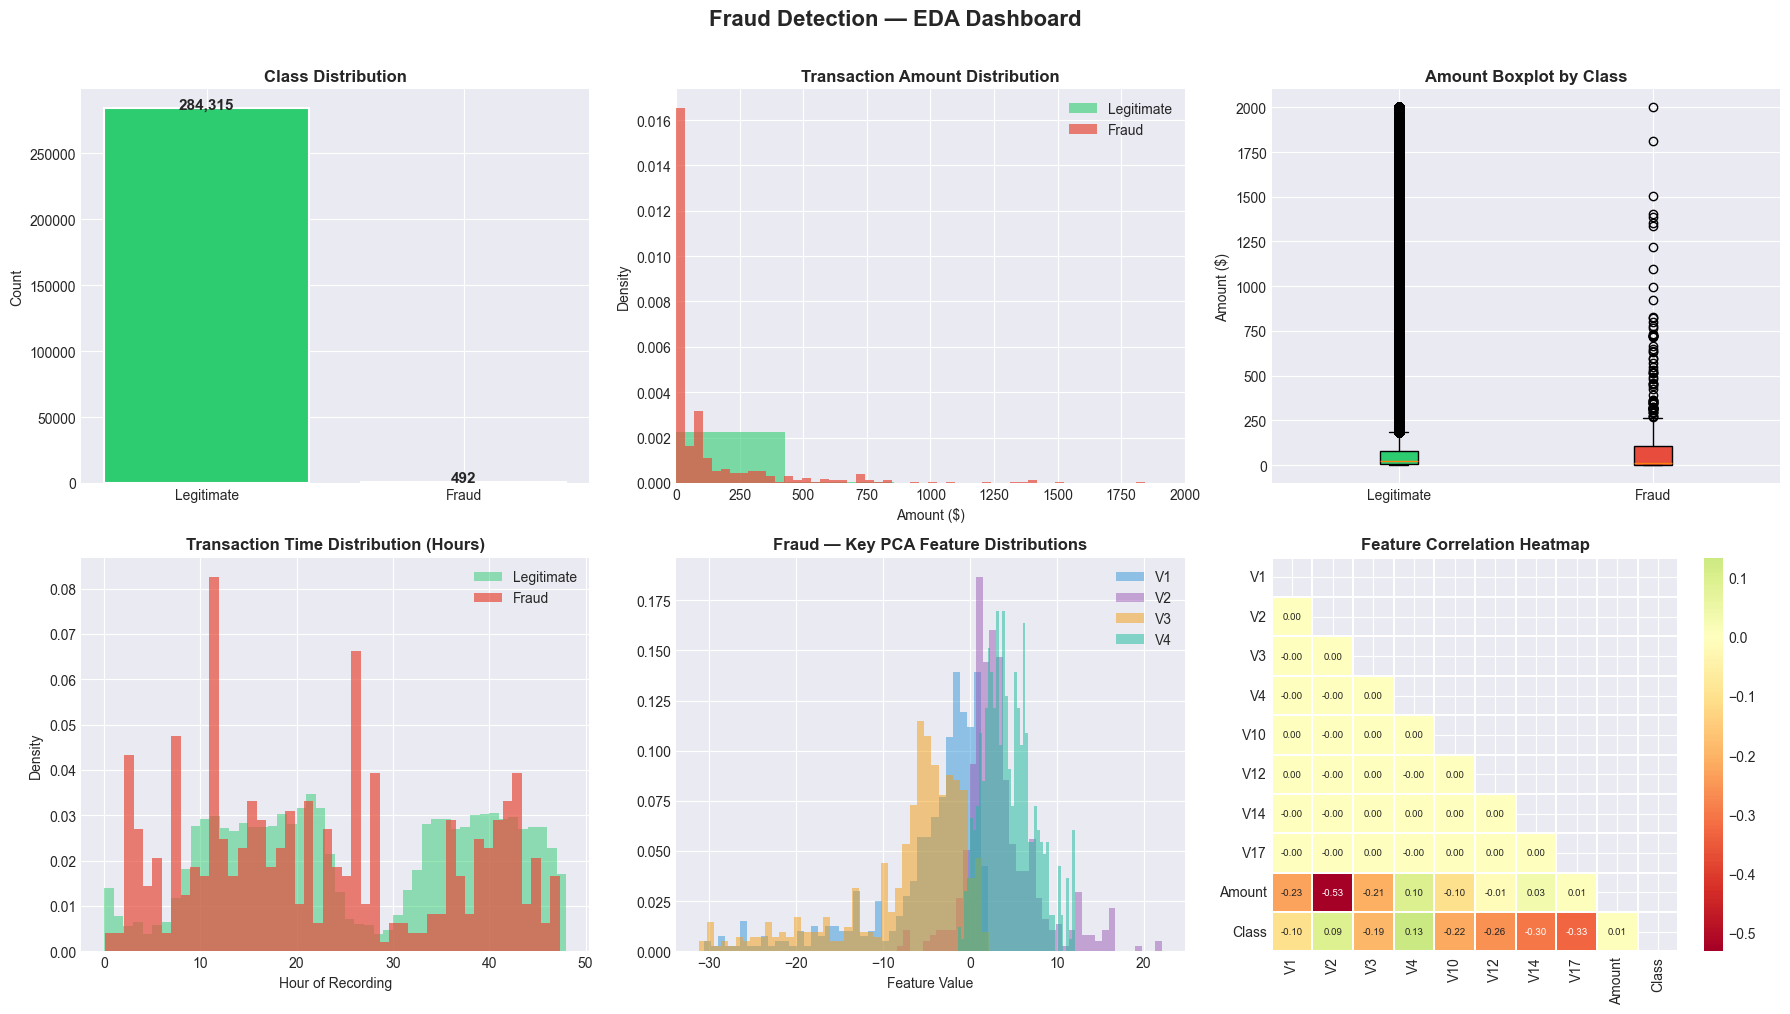

✅ EDA dashboard saved


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fraud Detection — EDA Dashboard', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Class Distribution ─────────────────────────────────────────────────────
ax = axes[0, 0]
counts = df['Class'].value_counts()
bars = ax.bar(['Legitimate', 'Fraud'], counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')

# ── 2. Transaction Amount by Class ───────────────────────────────────────────
ax = axes[0, 1]
ax.hist(legit['Amount'], bins=60, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
ax.hist(fraud['Amount'], bins=60, alpha=0.7, color='#e74c3c', label='Fraud',      density=True)
ax.set_title('Transaction Amount Distribution', fontweight='bold')
ax.set_xlabel('Amount ($)')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(0, 2000)

# ── 3. Fraud Amounts Boxplot ──────────────────────────────────────────────────
ax = axes[0, 2]
bp = ax.boxplot([legit['Amount'].clip(upper=2000), fraud['Amount'].clip(upper=2000)],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#ecf0f1'))
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_title('Amount Boxplot by Class', fontweight='bold')
ax.set_ylabel('Amount ($)')

# ── 4. Time-based Fraud Pattern ───────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(legit['Time'] / 3600,  bins=48, alpha=0.5, color='#2ecc71', label='Legitimate', density=True)
ax.hist(fraud['Time'] / 3600,  bins=48, alpha=0.7, color='#e74c3c', label='Fraud',      density=True)
ax.set_title('Transaction Time Distribution (Hours)', fontweight='bold')
ax.set_xlabel('Hour of Recording')
ax.set_ylabel('Density')
ax.legend()

# ── 5. Key Feature Distributions ─────────────────────────────────────────────
ax = axes[1, 1]
key_features = ['V1', 'V2', 'V3', 'V4']
colors = ['#3498db', '#9b59b6', '#f39c12', '#1abc9c']
for feat, color in zip(key_features, colors):
    ax.hist(fraud[feat], bins=40, alpha=0.5, color=color, label=feat, density=True)
ax.set_title('Fraud — Key PCA Feature Distributions', fontweight='bold')
ax.set_xlabel('Feature Value')
ax.legend()

# ── 6. Correlation Heatmap (selected features) ───────────────────────────────
ax = axes[1, 2]
selected = ['V1','V2','V3','V4','V10','V12','V14','V17','Amount','Class']
corr = df[selected].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA dashboard saved')

## ⚙️ 5. Preprocessing & SMOTE

In [5]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df['Hour']          = (df['Time'] / 3600) % 24          # hour of day
df['Amount_log']    = np.log1p(df['Amount'])             # log-transform skewed Amount
df['Amount_scaled'] = RobustScaler().fit_transform(df[['Amount']])

FEATURE_COLS = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Hour']
TARGET_COL   = 'Class'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size  : {X_train.shape}')
print(f'Test size   : {X_test.shape}')
print(f'Train fraud : {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Test  fraud : {y_test.sum()}  ({y_test.mean()*100:.3f}%)')

# ── SMOTE Oversampling ────────────────────────────────────────────────────────
print('\n🔄 Applying SMOTE...')
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, y_train.sum()-1))
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'After SMOTE — Legit: {(y_train_sm==0).sum():,}  |  Fraud: {(y_train_sm==1).sum():,}')
print('✅ Data ready for modelling')

Train size  : (227845, 30)
Test size   : (56962, 30)
Train fraud : 394 (0.173%)
Test  fraud : 98  (0.172%)

🔄 Applying SMOTE...
After SMOTE — Legit: 227,451  |  Fraud: 227,451
✅ Data ready for modelling


## 🤖 6. Model Training

In [6]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model', threshold=0.5):
    """Train, evaluate and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = dict(
        name      = name,
        model     = model,
        y_prob    = y_prob,
        roc_auc   = roc_auc_score(y_te, y_prob),
        avg_prec  = average_precision_score(y_te, y_prob),
        precision = precision_score(y_te, y_pred, zero_division=0),
        recall    = recall_score(y_te, y_pred, zero_division=0),
        f1        = f1_score(y_te, y_pred, zero_division=0),
        threshold = threshold,
    )
    return metrics


# ── Define models ─────────────────────────────────────────────────────────────
models_cfg = [
    ('Logistic Regression',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
    ('Decision Tree',
     DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE, class_weight='balanced')),
    ('Random Forest ⭐',
     RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
                            class_weight='balanced', n_jobs=-1)),
]

if XGB_AVAILABLE:
    scale_pw = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()
    models_cfg.append(('XGBoost',
        xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                          scale_pos_weight=1, use_label_encoder=False,
                          eval_metric='aucpr', random_state=RANDOM_STATE,
                          tree_method='hist')))

# ── Train all models ──────────────────────────────────────────────────────────
results = []
for name, model in models_cfg:
    print(f'Training {name}...', end=' ')
    res = evaluate_model(model, X_train_sm, y_train_sm, X_test, y_test, name)
    results.append(res)
    print(f'ROC-AUC={res["roc_auc"]:.4f}  Recall={res["recall"]:.4f}  F1={res["f1"]:.4f}')

print('\n✅ All models trained')

# Display comparison table
summary = pd.DataFrame([{
    'Model'    : r['name'],
    'ROC-AUC'  : f"{r['roc_auc']:.4f}",
    'Avg Prec' : f"{r['avg_prec']:.4f}",
    'Precision': f"{r['precision']:.4f}",
    'Recall'   : f"{r['recall']:.4f}",
    'F1'       : f"{r['f1']:.4f}",
} for r in results])
display(summary.style.set_caption('Model Comparison'))

Training Logistic Regression... ROC-AUC=0.9715  Recall=0.9082  F1=0.1042
Training Decision Tree... ROC-AUC=0.8895  Recall=0.8367  F1=0.1415
Training Random Forest ⭐... ROC-AUC=0.9860  Recall=0.8571  F1=0.6512
Training XGBoost... ROC-AUC=0.9801  Recall=0.8673  F1=0.6538

✅ All models trained


,Model,ROC-AUC,Avg Prec,Precision,Recall,F1
0,Logistic Regression,0.9715,0.7278,0.0552,0.9082,0.1042
1,Decision Tree,0.8895,0.4281,0.0773,0.8367,0.1415
2,Random Forest ⭐,0.9860,0.8202,0.5250,0.8571,0.6512
3,XGBoost,0.9801,0.8605,0.5247,0.8673,0.6538


## 📈 7. Visualise Results

In [ ]:
COLORS = ['#3498db','#2ecc71','#e74c3c','#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# ── ROC Curves ───────────────────────────────────────────────────────────────
ax = axes[0]
for res, color in zip(results, COLORS):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set(title='ROC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(fontsize=8)

# ── Precision–Recall Curves ───────────────────────────────────────────────────
ax = axes[1]
for res, color in zip(results, COLORS):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, color=color, lw=2,
            label=f"{res['name']} (AP={res['avg_prec']:.3f})")
ax.set(title='Precision–Recall Curves', xlabel='Recall', ylabel='Precision')
ax.legend(fontsize=8)

# ── Best Model Confusion Matrix ───────────────────────────────────────────────
best = max(results, key=lambda r: r['roc_auc'])
y_pred_best = (best['y_prob'] >= best['threshold']).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
ax = axes[2]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Legit','Pred: Fraud'],
            yticklabels=['Actual: Legit','Actual: Fraud'])
ax.set_title(f'Confusion Matrix — {best["name"]}', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n🏆 Best model: {best["name"]} (ROC-AUC={best["roc_auc"]:.4f})')

## 🎯 8. Threshold Tuning

In [ ]:
best_model = best['model']
y_prob     = best['y_prob']

thresholds = np.linspace(0.05, 0.95, 100)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

optimal_idx = np.argmax(f1s)
optimal_t   = thresholds[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Threshold Tuning', fontweight='bold', fontsize=14)

ax = axes[0]
ax.plot(thresholds, precisions, 'b-', lw=2, label='Precision')
ax.plot(thresholds, recalls,    'r-', lw=2, label='Recall')
ax.plot(thresholds, f1s,        'g-', lw=2, label='F1-score')
ax.axvline(optimal_t, color='black', linestyle='--', label=f'Optimal τ={optimal_t:.2f}')
ax.set(title='Metrics vs Threshold', xlabel='Threshold', ylabel='Score')
ax.legend()

ax = axes[1]
y_pred_opt = (y_prob >= optimal_t).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Pred: Legit','Pred: Fraud'],
            yticklabels=['Actual: Legit','Actual: Fraud'])
ax.set_title(f'Confusion Matrix @ τ={optimal_t:.2f}', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold : {optimal_t:.3f}')
print(f'Precision         : {precision_score(y_test, y_pred_opt, zero_division=0):.4f}')
print(f'Recall            : {recall_score(y_test, y_pred_opt, zero_division=0):.4f}')
print(f'F1-score          : {f1_score(y_test, y_pred_opt, zero_division=0):.4f}')

## 🌟 9. Feature Importance

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(feat_imp))]
    feat_imp.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {best["name"]}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top 10 most important features:')
    print(feat_imp.head(10).to_string())
else:
    print('Feature importances not available for this model type.')

## 🔮 10. SHAP Explainability

In [ ]:
if SHAP_AVAILABLE:
    print('Computing SHAP values (may take a minute)...')
    # Use a sample for speed
    X_shap = X_test[:min(500, len(X_test))]

    if hasattr(best_model, 'feature_importances_'):
        explainer  = shap.TreeExplainer(best_model)
        shap_vals  = explainer.shap_values(X_shap)
        # For binary classifier, take fraud class
        sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
    else:
        explainer = shap.LinearExplainer(best_model, X_train_sm)
        sv = explainer.shap_values(X_shap)

    shap_df = pd.DataFrame(X_shap, columns=FEATURE_COLS)

    # ── Summary Plot ──────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, shap_df, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance (Global)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Beeswarm Plot ─────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, shap_df, show=False)
    plt.title('SHAP Beeswarm — Feature Impact on Fraud Prediction', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('✅ SHAP analysis complete')
else:
    print('Install SHAP: pip install shap')

## 💼 11. Business Insights

In [ ]:
print('=' * 60)
print('BUSINESS INSIGHTS')
print('=' * 60)

# ── Amount thresholds ─────────────────────────────────────────────────────────
high_amount_threshold = df['Amount'].quantile(0.90)
high_amount_fraud_rate = df[df['Amount'] > high_amount_threshold]['Class'].mean() * 100
overall_fraud_rate     = df['Class'].mean() * 100

print(f'\n📌 Amount-based risk:')
print(f'   Transactions > ${high_amount_threshold:.0f} (90th pct) → '
      f'{high_amount_fraud_rate:.2f}% fraud rate')
print(f'   vs. overall fraud rate of {overall_fraud_rate:.4f}%')
print(f'   Risk multiplier: {high_amount_fraud_rate/overall_fraud_rate:.1f}x higher')

# ── Time-based patterns ───────────────────────────────────────────────────────
df['Hour_bin'] = (df['Time'] / 3600).astype(int) % 24
hourly = df.groupby('Hour_bin')['Class'].agg(['sum','count'])
hourly['fraud_rate'] = hourly['sum'] / hourly['count'] * 100
peak_hour = hourly['fraud_rate'].idxmax()

print(f'\n📌 Time-based risk:')
print(f'   Peak fraud hour   : Hour {peak_hour} '
      f'({hourly.loc[peak_hour, "fraud_rate"]:.2f}% fraud rate)')
print(f'   Low fraud hours   : {hourly["fraud_rate"].nsmallest(3).index.tolist()}')

# ── Model business value ──────────────────────────────────────────────────────
avg_fraud_amount = fraud['Amount'].mean()
tp = cm_opt[1,1]
fn = cm_opt[1,0]
fp = cm_opt[0,1]

print(f'\n📌 Model business value:')
print(f'   Avg fraudulent txn amount : ${avg_fraud_amount:.2f}')
print(f'   True Positives (caught)   : {tp}')
print(f'   False Negatives (missed)  : {fn}')
print(f'   False Positives (false alarm): {fp}')
print(f'   Estimated savings         : ${tp * avg_fraud_amount:,.0f}')
print(f'   Missed fraud losses       : ${fn * avg_fraud_amount:,.0f}')

## 💾 12. Save Model

In [ ]:
os.makedirs('../models', exist_ok=True)

model_bundle = {
    'model'         : best_model,
    'model_name'    : best['name'],
    'features'      : FEATURE_COLS,
    'threshold'     : optimal_t,
    'scaler'        : RobustScaler().fit(df[['Amount']]),
    'roc_auc'       : best['roc_auc'],
    'training_date' : pd.Timestamp.now().isoformat(),
}

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('✅ Model bundle saved to ../models/model.pkl')
print(f'   Model      : {best["name"]}')
print(f'   ROC-AUC    : {best["roc_auc"]:.4f}')
print(f'   Threshold  : {optimal_t:.3f}')
print(f'   Features   : {len(FEATURE_COLS)}')